<a href="https://colab.research.google.com/github/gopalasthana24/aps-gopal/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greedy Knapsack Problem (Fractional)
In this lab, we explore the Fractional Knapsack Problem, a fundamental optimization problem that demonstrates the Greedy Algorithmic Paradigm.
We will implement it using greedy selection (based on value-to-weight ratio) and analyze its time and space complexity.

- Created by Dr. Ajay

# Problem Definition
Given a set of
n
n items, each with:
Value vi
Weight wi
A knapsack with maximum capacity **W**

Goal: maximize total value that can be put in the knapsack.
Constraint: You may take fractions of items.

Greedy Strategy:

*  Sort items by decreasing ratio vi/wi
*  Select items fully until knapsack is full.
*  Take fraction of the next item if capacity remains.

In [1]:
#write code for the above problem

class Item:
    def __init__(self, value, weight):
        self.value = value
        self.weight = weight
        self.ratio = value / weight

def fractional_knapsack(values, weights, capacity):
    items = [Item(values[i], weights[i]) for i in range(len(values))]

    items.sort(key=lambda x: x.ratio, reverse=True)

    total_value = 0.0
    remaining_capacity = capacity

    for item in items:
        if remaining_capacity >= item.weight:
            total_value += item.value
            remaining_capacity -= item.weight
        else:
            fraction = remaining_capacity / item.weight
            total_value += item.value * fraction
            break
    return total_value


values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50

max_value = fractional_knapsack(values, weights, capacity)
print("Maximum value in Knapsack =", max_value)


Maximum value in Knapsack = 240.0


In this lab, we implement Huffman Coding, a greedy algorithm used for lossless data compression.
It assigns variable-length binary codes to input symbols based on their frequencies, ensuring that more frequent symbols receive shorter codes and less frequent symbols receive longer codes.

This algorithm constructs a binary tree (Huffman Tree) where each leaf node represents a character, and the path from the root to a leaf gives the character’s binary code.

Use:
Huffman Tree Construction using a Min-Priority Queue (Min-Heap).
Code generation for each character.
Encoding and decoding using the generated Huffman codes.
Complexity analysis and comparison with fixed-length encoding.

# Pseudocode:
1. Create a leaf node for each character and insert all nodes into a
2. min-heap by frequency.
   *  While the heap has more than one node:
   * Extract two nodes with the lowest frequencies.
   * Create a new internal node with frequency = sum of the two.
   *  Set the two extracted nodes as left and right children.
   *  Insert the new node back into the min-heap.
3. The remaining node is the root of the Huffman Tree.

4. Traverse the tree:
   * Assign 0 for left edge and 1 for right edge.
   * The resulting paths from root to leaves give Huffman codes.

Original Text: huffman coding algorithm
Huffman Codes: {'a': '000', 'h': '001', 'l': '0100', 'd': '0101', 'n': '011', 'm': '1000', 'o': '1001', 'i': '1010', 't': '10110', 'r': '10111', ' ': '1100', 'f': '1101', 'g': '1110', 'u': '11110', 'c': '11111'}
Encoded Text: 0011111011011101100000001111001111110010101101001111101100000010011101001101111010101100011000
Decoded Text: huffman coding algorithm


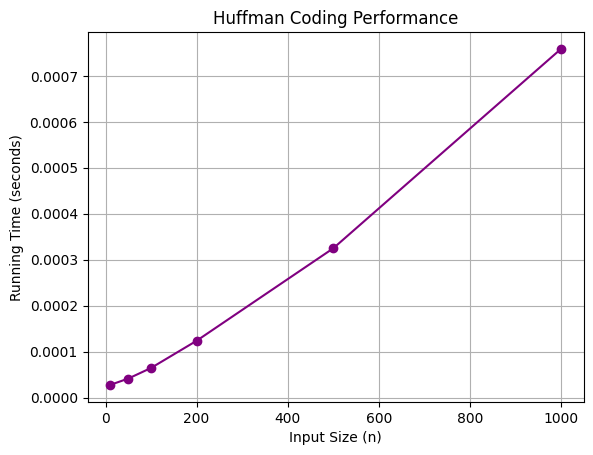

In [2]:
# write code for above
import heapq
import time
import matplotlib.pyplot as plt

class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(char_freq):
    heap = [Node(char, freq) for char, freq in char_freq.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right

        heapq.heappush(heap, merged)

    return heap[0]
def generate_codes(node, current_code="", codes={}):
    if node is None:
        return

    if node.char is not None:
        codes[node.char] = current_code

    generate_codes(node.left, current_code + "0", codes)
    generate_codes(node.right, current_code + "1", codes)

    return codes


def huffman_encode(text, codes):
    return "".join(codes[char] for char in text)


def huffman_decode(encoded_text, root):
    decoded_text = ""
    current = root
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char is not None:
            decoded_text += current.char
            current = root
    return decoded_text


text = "huffman coding algorithm"
print("Original Text:", text)

char_freq = {}
for char in text:
    char_freq[char] = char_freq.get(char, 0) + 1

root = build_huffman_tree(char_freq)

codes = generate_codes(root)
print("Huffman Codes:", codes)

encoded_text = huffman_encode(text, codes)
print("Encoded Text:", encoded_text)

decoded_text = huffman_decode(encoded_text, root)
print("Decoded Text:", decoded_text)


sizes = [10, 50, 100, 200, 500, 1000]
times = []

for size in sizes:
    test_text = "a" * size + "b" * size + "c" * size
    char_freq = {}
    for char in test_text:
        char_freq[char] = char_freq.get(char, 0) + 1

    start = time.time()
    root = build_huffman_tree(char_freq)
    codes = generate_codes(root)
    encoded = huffman_encode(test_text, codes)
    decoded = huffman_decode(encoded, root)
    end = time.time()

    times.append(end - start)

plt.plot(sizes, times, marker='o', color='purple')
plt.xlabel("Input Size (n)")
plt.ylabel("Running Time (seconds)")
plt.title("Huffman Coding Performance")
plt.grid(True)
plt.show()